# MSA 2026 Phase 2 - Part 2: Maximum Temperature Prediction from Weather Data

In [207]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load and check the dataset

In [191]:
# Load weather data from the csv file

weather_data = pd.read_csv('Summary of Weather.csv')
weather_data.head()

C:\Users\ivyta\AppData\Local\Temp\ipykernel_13180\2646630040.py:3: DtypeWarning: Columns (0: Snowfall, 1: PoorWeather, 2: SNF, 3: TSHDSBRSGF) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_data = pd.read_csv('Summary of Weather.csv')


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942-7-1,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942-7-2,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942-7-3,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942-7-4,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942-7-5,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.1 Examine Data types and missing values

In [192]:
# Check data types and missing values
weather_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  str    
 2   Precip       119040 non-null  str    
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  str    
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877 non-null  objec

* **Observation**: There are 119040 records and 31 variables.

In [193]:
# Found there are quite a few missing values in the dataset. 
# So check the portion of missing values for each column.
missing_values = (
    weather_data
    .isna()
    .sum()
    .sort_values(ascending=False)
)

summary_missing = pd.DataFrame({
    'Missing_value_count': missing_values,
    'Percentage': (missing_values / len(weather_data)) * 100
})
summary_missing

,Missing_value_count,Percentage
SD3,119040,100.000000
RHN,119040,100.000000
RHX,119040,100.000000
RVG,119040,100.000000
FT,119040,100.000000
FTI,119040,100.000000
WTE,119040,100.000000
ITH,119040,100.000000
FB,119040,100.000000
PGT,118515,99.558972


* **Decision:** For variables >95% missing values, **consider to drop them** later during data cleaning **as these features provide insufficient information.**

### 1.2 Investigate duplicate records

In [194]:
# Check duplicates
duplicates = weather_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Examine duplicate values in detail
weather_data[
    weather_data.duplicated(keep=False)
]

Number of duplicate rows: 10


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
94650,34139,1945-6-21,0.508,NaN,35.000000,18.888889,26.666667,0.0,1,45,...,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
94651,34139,1945-6-22,0,NaN,34.444444,18.888889,26.666667,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94652,34139,1945-6-23,0,NaN,36.666667,17.222222,26.666667,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94653,34139,1945-6-24,0,NaN,37.222222,16.111111,26.666667,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94654,34139,1945-6-25,0,NaN,38.333333,18.333333,28.333333,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94655,34139,1945-6-26,2.54,NaN,32.777778,19.444444,26.111111,0.0,1,45,...,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
94656,34139,1945-6-27,T,NaN,30.555556,20.000000,25.555556,0.0,1,45,...,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
94657,34139,1945-6-28,0,NaN,30.000000,20.000000,25.000000,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
94658,34139,1945-6-29,1.27,NaN,30.000000,20.000000,25.000000,0.0,1,45,...,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
94659,34139,1945-6-30,0,NaN,32.777778,16.666667,24.444444,0.0,NaN,45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* **Decision:** After detailed investigation on each duplicate records, decided to drop them during data cleaning as they provide redundant information.

### 1.3 Understand unique value of each variable for correction on data type

In [195]:
# Check number of unique values and first 10 values for each column
# so that we can decide the data types; output in a summary table
summary_unique = pd.DataFrame()
for column in weather_data.columns:
    unique_values = weather_data[column].nunique()
    first_10_values = weather_data[column].unique()[:10]
    summary_unique = pd.concat([summary_unique, pd.DataFrame({'Column': [column], 
                                                              'Unique_Values': [unique_values], 
                                                              'First_10_Values': [first_10_values]})])

summary_unique

,Column,Unique_Values,First_10_Values
0,STA,159,"[10001, 10002, 10101, 10102, 10502, 10505, 107..."
0,Date,2192,"[1942-7-1, 1942-7-2, 1942-7-3, 1942-7-4, 1942-..."
0,Precip,540,"[1.016, 0, 2.54, T, 3.556, 0.508, 0.254, 1.778..."
0,WindGustSpd,30,"[nan, 29.632, 59.264, 50.004, 40.744, 51.856, ..."
0,MaxTemp,149,"[25.55555556, 28.88888889, 26.11111111, 26.666..."
0,MinTemp,132,"[22.22222222, 21.66666667, 22.77777778, 21.111..."
0,MeanTemp,136,"[23.88888889, 25.55555556, 24.44444444, 25.0, ..."
0,Snowfall,42,"[0.0, nan, 0, 22.86, 33.02, 30.48, 2.54, 5.08,..."
0,PoorWeather,39,"[nan, 1, 1 1, 1 1, 1 1 1, 1 1, 1 ..."
0,YR,6,"[42, 43, 44, 45, 41, 40]"


* **Observation**: Found non-numeric values like "T" in Precipitation, so need to double check if string/object columns can be converted into numeric 

In [196]:
# Define a function to check all object and string columns, find out values 
# that cannot be converted to numeric;
# for example, in the 'precip' column, there are some values like 'T' which is not a number.
def check_strobj_columns(df, columns=None):

    if columns is None:
        columns = df.select_dtypes(include=['object', 'string']).columns

    results = {}

    for col in columns:

        converted = pd.to_numeric(df[col], errors="coerce")
        # Find values that failed conversion but are not missing and 
        # count their occurrences
        special = (
            df.loc[
                converted.isna() & df[col].notna(),
                col
            ]
            .value_counts()
        )

        results[col] = special
    
        if special.empty:
            print(f"{col}: All values are numeric.")
        else:
            print(f"{col}: Non-numeric values found:")
            print(special)
            print("="*50)

    return results

# Apply on weather_data
special_results = check_strobj_columns(weather_data)

Date: Non-numeric values found:
Date
1945-4-16     122
1945-4-17     122
1945-4-19     122
1945-4-20     122
1945-4-22     122
             ... 
1940-1-28       3
1940-1-29       3
1940-1-30       3
1940-1-31       3
1940-12-25      3
Name: count, Length: 2192, dtype: int64
Precip: Non-numeric values found:
Precip
T    16753
Name: count, dtype: int64
Snowfall: Non-numeric values found:
Snowfall
#VALUE!    44
Name: count, dtype: int64
PoorWeather: Non-numeric values found:
PoorWeather
1     1       310
1 1           133
1 1  1         96
1    1         56
1  1           49
1   1 1        14
11 1            8
1     1  1      5
11    1         5
1 0  1          2
1   1 1  1      2
1        1      1
1     0         1
1 0             1
1   1           1
Name: count, dtype: int64
PRCP: Non-numeric values found:
PRCP
T    16753
Name: count, dtype: int64
SNF: Non-numeric values found:
SNF
T    44
Name: count, dtype: int64
TSHDSBRSGF: Non-numeric values found:
TSHDSBRSGF
1     1       310
1 1  

In [197]:
# For columns like Precip, Snowfall, PRCP, SNF, check portion of those non-numeric values
# Output in a summary table

def special_value_summary(results, selected_columns):
    '''Function to summarise the count and percentage of special values 
    in each column.'''

    summary = []

    for col, series in results.items():

        if series.empty:
            continue

        for value, count in series.items():

            summary.append({
                "Variable": col,
                "Special Value": value,
                "Count": count,
                "Percentage (%)": round(count / selected_columns * 100, 2)
            })

    return (
        pd.DataFrame(summary)
        .sort_values(["Variable", "Count"], ascending=[True, False])
        .reset_index(drop=True)
    )

selected_columns = check_strobj_columns(
    weather_data,
    ["Precip", "Snowfall", "PRCP", "SNF"]
)

summary_table = special_value_summary(
    selected_columns,
    len(weather_data)
)

summary_table

Precip: Non-numeric values found:
Precip
T    16753
Name: count, dtype: int64
Snowfall: Non-numeric values found:
Snowfall
#VALUE!    44
Name: count, dtype: int64
PRCP: Non-numeric values found:
PRCP
T    16753
Name: count, dtype: int64
SNF: Non-numeric values found:
SNF
T    44
Name: count, dtype: int64


,Variable,Special Value,Count,Percentage (%)
0,PRCP,T,16753,14.07
1,Precip,T,16753,14.07
2,SNF,T,44,0.04
3,Snowfall,#VALUE!,44,0.04


* **Decision:** The value **"T"** could not be interpreted because the dataset documentation was unavailable. Instead of assigning an arbitrary numeric value, these entries will **be converted to missing values** and handled together during the missing-value imputation stage. The **rest numeric values** will be **converted into numeric type** in data cleaning process
    
    **"#VALUE!"** is considered as data error. Hence, will **be turned into missing** as well.



In [198]:
# Check if PoorWeather & TSHDSBRSGF are exactly the same
print(weather_data["PoorWeather"].equals(weather_data["TSHDSBRSGF"]))


True


* **Decision: values in PoorWeather and TSHDSBRSGF are exactly the same,** suspect that they provide redundant or correlated information. Considering that their **meanings are not defined and 71% of the values are missing**, decide to **exclude them** from machine learning task.

## 2. Clean the dataset, drop variables

### 2.1 Drop columns with >95% missing values & duplicates

In [226]:
# Drop variables with >95% missing values
columns_to_drop = summary_missing[summary_missing['Percentage'] > 95].index
weather_data_model = weather_data.drop(columns=columns_to_drop)

# Drop duplicates
weather_data_model = weather_data_model.drop_duplicates()
weather_data_model.info()

<class 'pandas.DataFrame'>
Index: 119030 entries, 0 to 119039
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119030 non-null  int64  
 1   Date         119030 non-null  str    
 2   Precip       119030 non-null  str    
 3   MaxTemp      119030 non-null  float64
 4   MinTemp      119030 non-null  float64
 5   MeanTemp     119030 non-null  float64
 6   Snowfall     117867 non-null  object 
 7   PoorWeather  34233 non-null   object 
 8   YR           119030 non-null  int64  
 9   MO           119030 non-null  int64  
 10  DA           119030 non-null  int64  
 11  PRCP         117098 non-null  str    
 12  MAX          118556 non-null  float64
 13  MIN          118562 non-null  float64
 14  MEA          118532 non-null  float64
 15  SNF          117867 non-null  object 
 16  TSHDSBRSGF   34233 non-null   object 
dtypes: float64(6), int64(4), object(4), str(3)
memory usage: 16.3+ MB


### 2.2 Handle special values in Precip, Snowfall, PRCP, SNF columns

In [227]:
# Turn the non-numeric values in the selected columns into NaN
# convert the columns to numeric type
for col, values in selected_columns.items():
    weather_data_model[col] = weather_data_model[col].replace(values.index.tolist(), np.nan)

# check if non-numeric values in the selected columns have been replaced with NaN
check_strobj_columns(weather_data_model, ["Precip", "Snowfall", "PRCP", "SNF"])

Precip: All values are numeric.
Snowfall: All values are numeric.
PRCP: All values are numeric.
SNF: All values are numeric.


{'Precip': Series([], Name: count, dtype: int64),
 'Snowfall': Series([], Name: count, dtype: int64),
 'PRCP': Series([], Name: count, dtype: int64),
 'SNF': Series([], Name: count, dtype: int64)}

### 2.3 Correct data types and drop redundant columns

#### 2.3.1 Station ID

In [228]:
# Make station ID "STA" string type as this is identifier and should not 
# be treated as numeric
weather_data_model['STA'] = weather_data_model['STA'].astype(str)

#### 2.3.2 Date

In [229]:
# Turn "Date" into datetime type, get Year, Month, Day from it.
weather_data_model['Date'] = pd.to_datetime(weather_data_model['Date'], 
                                            format='%Y-%m-%d')

# Get the last 2 digts of year
weather_data_model['Year'] = weather_data_model['Date'].dt.year
weather_data_model['Year_2digit'] = weather_data_model['Date'].dt.strftime('%y').astype(int)
weather_data_model['Month'] = weather_data_model['Date'].dt.month
weather_data_model['Day'] = weather_data_model['Date'].dt.day

# Cross check with the YR, MO, DA columns, if they are redundant, 
# drop the YR, MO,DA columns
comparison = pd.DataFrame({
    "Year Match": weather_data_model["Year_2digit"] == weather_data_model["YR"],
    "Month Match": weather_data_model["Month"] == weather_data_model["MO"],
    "Day Match": weather_data_model["Day"] == weather_data_model["DA"]
})

print(comparison.all())
weather_data_model.head()

Year Match     True
Month Match    True
Day Match      True
dtype: bool


,STA,Date,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,MO,...,PRCP,MAX,MIN,MEA,SNF,TSHDSBRSGF,Year,Year_2digit,Month,Day
0,10001,1942-07-01,1.016,25.555556,22.222222,23.888889,0.0,NaN,42,7,...,0.04,78.0,72.0,75.0,0.0,NaN,1942,42,7,1
1,10001,1942-07-02,0,28.888889,21.666667,25.555556,0.0,NaN,42,7,...,0,84.0,71.0,78.0,0.0,NaN,1942,42,7,2
2,10001,1942-07-03,2.54,26.111111,22.222222,24.444444,0.0,NaN,42,7,...,0.1,79.0,72.0,76.0,0.0,NaN,1942,42,7,3
3,10001,1942-07-04,2.54,26.666667,22.222222,24.444444,0.0,NaN,42,7,...,0.1,80.0,72.0,76.0,0.0,NaN,1942,42,7,4
4,10001,1942-07-05,0,26.666667,21.666667,24.444444,0.0,NaN,42,7,...,0,80.0,71.0,76.0,0.0,NaN,1942,42,7,5


In [230]:
# Drop the Date, Year_2digit, YR, MO, DA columns
weather_data_model = weather_data_model.drop(columns=['Date','Year_2digit','YR', 'MO', 'DA'])

#### 2.3.3 'Precip','Snowfall','PRCP','SNF'

In [231]:
# Make numeric columns numeric type
numeric_columns = ['Precip','Snowfall','PRCP','SNF']
for col in numeric_columns:
    weather_data_model[col] = pd.to_numeric(weather_data_model[col], errors='coerce')

weather_data_model.info()

<class 'pandas.DataFrame'>
Index: 119030 entries, 0 to 119039
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119030 non-null  str    
 1   Precip       102278 non-null  float64
 2   MaxTemp      119030 non-null  float64
 3   MinTemp      119030 non-null  float64
 4   MeanTemp     119030 non-null  float64
 5   Snowfall     117823 non-null  float64
 6   PoorWeather  34233 non-null   object 
 7   PRCP         100346 non-null  float64
 8   MAX          118556 non-null  float64
 9   MIN          118562 non-null  float64
 10  MEA          118532 non-null  float64
 11  SNF          117823 non-null  float64
 12  TSHDSBRSGF   34233 non-null   object 
 13  Year         119030 non-null  int32  
 14  Month        119030 non-null  int32  
 15  Day          119030 non-null  int32  
dtypes: float64(10), int32(3), object(2), str(1)
memory usage: 14.1+ MB


#### 2.3.4 Drop "PoorWeather" and "TSHDSBRSGF" columns

In [232]:
# Drop "PoorWeather", "TSHDSBRSGF" columns
weather_data_model = weather_data_model.drop(columns=["PoorWeather", "TSHDSBRSGF"])
weather_data_model.head()

,STA,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,PRCP,MAX,MIN,MEA,SNF,Year,Month,Day
0,10001,1.016,25.555556,22.222222,23.888889,0.0,0.04,78.0,72.0,75.0,0.0,1942,7,1
1,10001,0.000,28.888889,21.666667,25.555556,0.0,0.00,84.0,71.0,78.0,0.0,1942,7,2
2,10001,2.540,26.111111,22.222222,24.444444,0.0,0.10,79.0,72.0,76.0,0.0,1942,7,3
3,10001,2.540,26.666667,22.222222,24.444444,0.0,0.10,80.0,72.0,76.0,0.0,1942,7,4
4,10001,0.000,26.666667,21.666667,24.444444,0.0,0.00,80.0,71.0,76.0,0.0,1942,7,5


### 2.4 Check data distribution 

In [233]:
weather_data_model.describe()

,Precip,MaxTemp,MinTemp,MeanTemp,Snowfall,PRCP,MAX,MIN,MEA,SNF,Year,Month,Day
count,102278.000000,119030.000000,119030.000000,119030.000000,117823.000000,100346.000000,118556.000000,118562.000000,118532.000000,117823.000000,119030.000000,119030.000000,119030.000000
mean,3.754205,27.044545,17.789446,22.411320,0.245564,0.150649,81.002750,64.273713,72.644307,0.009668,1943.805184,6.726077,15.796715
std,11.567099,8.717924,8.334910,8.298256,2.626711,0.459294,14.869516,14.482087,14.211550,0.103414,1.136713,3.425698,8.794421
min,0.000000,-33.333333,-38.333333,-35.555556,0.000000,0.000000,-28.000000,-37.000000,-32.000000,0.000000,1940.000000,1.000000,1.000000
25%,0.000000,25.555556,15.000000,20.555556,0.000000,0.000000,78.000000,59.000000,69.000000,0.000000,1943.000000,4.000000,8.000000
50%,0.000000,29.444444,21.111111,25.555556,0.000000,0.000000,85.000000,70.000000,78.000000,0.000000,1944.000000,7.000000,16.000000
75%,1.524000,31.666667,23.333333,27.222222,0.000000,0.070000,89.000000,74.000000,81.000000,0.000000,1945.000000,10.000000,23.000000
max,307.340000,50.000000,34.444444,40.000000,86.360000,12.100000,122.000000,94.000000,104.000000,3.400000,1945.000000,12.000000,31.000000


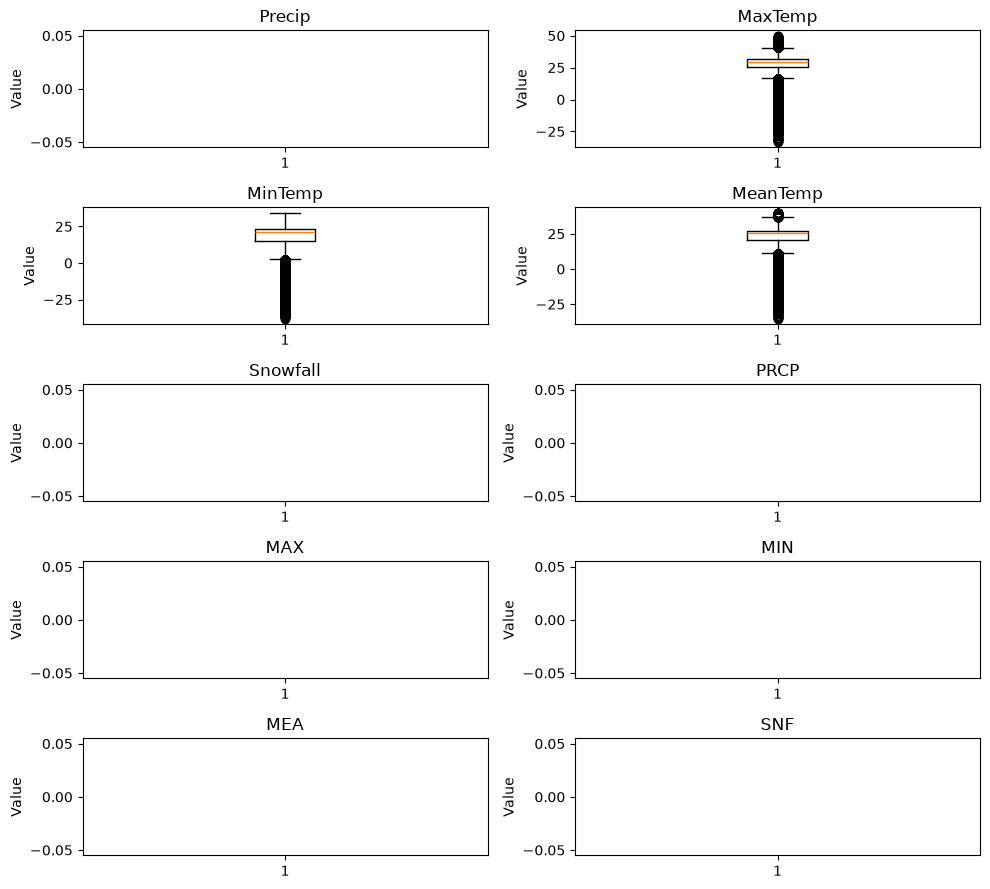

In [236]:
# Visualise with boxplots: remove year, month, day and station ID columns just for the sake of
# boxplot visualisation.
weather_data_boxplot = weather_data_model.drop(columns=['Year', 'Month', 'Day', 'STA'])
# Create subplots for each numeric column
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(10, 9))
axes = axes.ravel()

for i, col in enumerate(weather_data_boxplot.select_dtypes(include=['float64', 'int64']).columns):
    axes[i].boxplot(weather_data_boxplot[col])
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()


* **Decision:** **No standardisation** is required as all numeric variables are within similar scales

## 3. Select the feature(s) for the model, and explain the reason

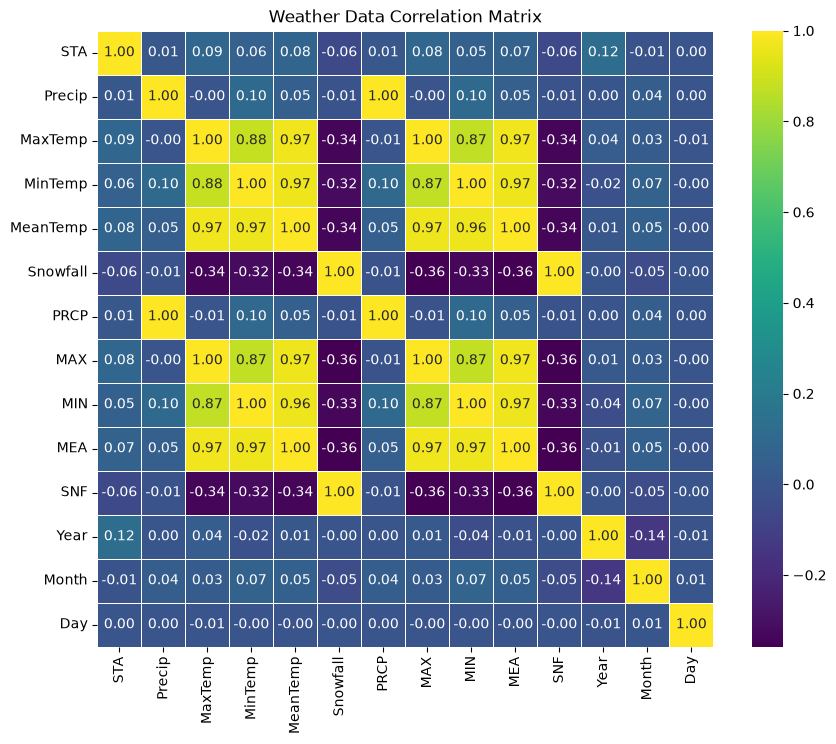

In [217]:
# Check correlation between numeric variables and visualise it using a heatmap
correlation_matrix = weather_data_model.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='viridis',
    cbar=True,
    square=True,
    linewidths=0.5
)
plt.title('Weather Data Correlation Matrix')
plt.show()


* **Decision:** To avoid multicollinearity, need to remove highly-correlated columns (Pearson correlation coefficient>0.90): 
    1) duplicate variables (Pearson correlation coefficient=1.00): **PRCP, MAX, MIN, MEA, SNF**
    2) variables where target feature (MaxTemp) was derived from: **MinTemp, MeanTemp**

In [ ]:
# Remove PRCP, MAX, MIN, MEA, SNF,MinTemp, MeanTemp columns
weather_data_model = weather_data_model.drop(['PRCP', 'MAX', 'MIN', 
                                              'MEA', 'SNF', 'MinTemp', 
                                              'MeanTemp'], axis=1)

In [ ]:
# Encode it as Station ID represents fixed locations with distinct climate patterns. 
# Although it is an identifier, it contains useful spatial information.
weather_data_model = pd.get_dummies(weather_data_model, columns=['STA'], prefix='STA')
weather_data_model.head()

,Precip,MaxTemp,Snowfall,Year,Month,Day,STA_10001,STA_10002,STA_10101,STA_10102,...,STA_81601,STA_81702,STA_82402,STA_82403,STA_82404,STA_82405,STA_82501,STA_82502,STA_82503,STA_82506
0,1.016,25.555556,0.0,1942,7,1,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.000,28.888889,0.0,1942,7,2,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2.540,26.111111,0.0,1942,7,3,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2.540,26.666667,0.0,1942,7,4,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.000,26.666667,0.0,1942,7,5,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 4. Split the dataset (70% for training, 30% for testing)

In [ ]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X = weather_data_model.drop('MaxTemp', axis=1) 
y = weather_data_model['MaxTemp']

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42)

## 5. Choose the algorithm, train and test the model

### 5.1 Linear Regression

In [225]:
# Check missing values in training set
missing_train = X_train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)

missing_train

Precip      11688
Snowfall      840
dtype: int64

In [223]:
# Train a Linear Regression model to predict MaxTemp
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## 6. Evaluate and Visualize model Performance

## 7. What is the R² value and RMSE of the model? How these values indicate the model performance?

In [77]:
# write your answer here

## 8. Discuss the model performance based on the plot

In [78]:
# write your answer here